In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, data, exposure
import imagecodecs
import os

In [10]:
directory_c = 'data/SELMA3D2026_training_annotated/contiguous_structures/raw/'
directory_i = 'data/SELMA3D2026_training_annotated/isolated_structures/raw/'

def load_data(directory, condition):
    data_dense = []
    data_sparse = []
    for entry in os.scandir(directory):
        if entry.is_file():
            img = io.imread(entry.path)
            if condition in entry.path:
                data_dense.append(img.ravel())
            else:
                data_sparse.append(img.ravel())
    return np.concatenate(data_dense), np.concatenate(data_sparse)

all_data_c_d, all_data_c_s = load_data(directory_c, 'blood')
all_data_i_d, all_data_i_s = load_data(directory_i, 'AD')

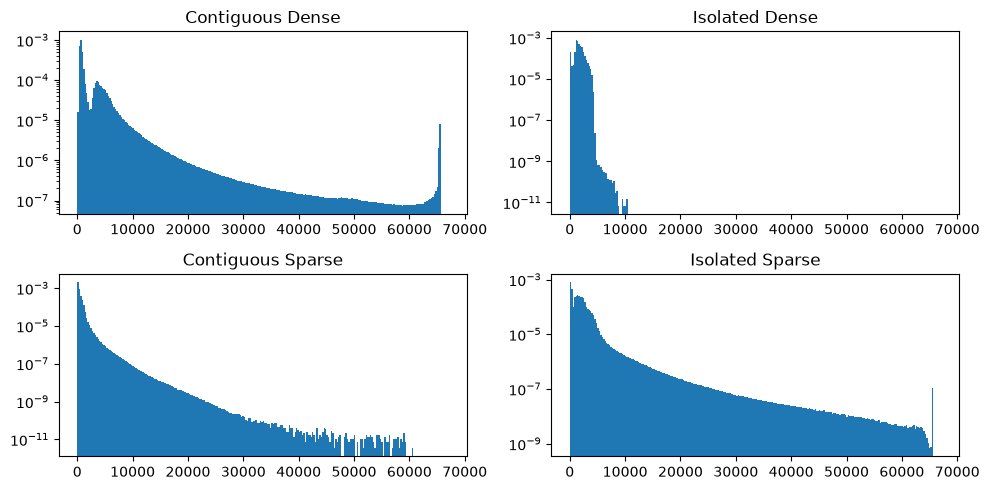

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10, 5))
axes[0, 0].hist(all_data_c_d, bins=256, range=(0, 67000), density=True)
axes[0, 0].set_title('Contiguous Dense')
axes[0,0].set_yscale('log')
axes[0, 1].hist(all_data_i_d, bins=256, range=(0, 67000), density=True)
axes[0, 1].set_title('Isolated Dense')
axes[0,1].set_yscale('log')
axes[1, 0].hist(all_data_c_s, bins=256, range=(0, 67000), density=True)
axes[1, 0].set_title('Contiguous Sparse')
axes[1, 0].set_yscale('log')
axes[1, 1].hist(all_data_i_s, bins=256, range=(0, 67000), density=True)
axes[1, 1].set_title('Isolated Sparse')
axes[1, 1].set_yscale('log')
plt.tight_layout()
plt.show()
